<a href="https://colab.research.google.com/github/IrisCheon/nlp-practice/blob/main/Spam_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spam Classification Practice

- A TF-IDF + Multinomial Naive Bayes baseline performed well on SMS spam classification.
- This may be because spam messages contain strong lexical signals such as promotional or urgent terms, and TF-IDF already downweights very common words.
- Threshold analysis showed how stricter or looser spam classification changes precision and recall.
- Removing English stop words did not meaningfully change the results in this experiment.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
base_path = r'/content/drive/MyDrive/1. data/dataset/spam_collection'
file_path = os.path.join(base_path, 'SMSSpamCollection')
df = pd.read_csv(file_path, sep="\t", header=None )
df.columns = ["label", "text"]
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


#■ 데이터 확인

In [3]:
df.shape

(5572, 2)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [9]:
df.describe()

,label,text
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [11]:
df[df['label']=='ham'].count()

,0
label,4825
text,4825


In [12]:
df[df['label']=='spam'].count()

,0
label,747
text,747


In [13]:
df['is_spam'] = df['label'].map({
    "ham" : 0,
    "spam" : 1
})

df.head()

,label,text,is_spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [17]:
df['is_spam'].mean().round(2)

np.float64(0.13)

In [19]:
df["text_length"] = df['text'].str.len()
df.head()

,label,text,is_spam,text_length
0,ham,"Go until jurong point, crazy.. Available only ...",0,111
1,ham,Ok lar... Joking wif u oni...,0,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155
3,ham,U dun say so early hor... U c already then say...,0,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61


In [20]:
df.groupby("label")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.482487,58.440652,2.0,33.0,52.0,93.0,910.0
spam,747.0,138.670683,28.873603,13.0,133.0,149.0,157.0,223.0


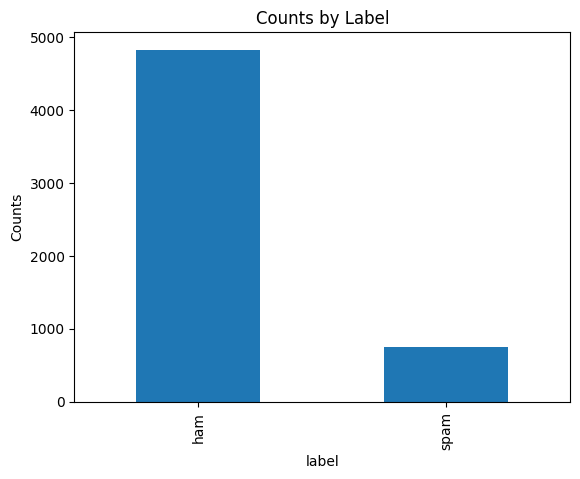

In [34]:
df["label"].value_counts().plot(kind="bar")

plt.title("Counts by Label")
plt.ylabel("Counts")
plt.show()

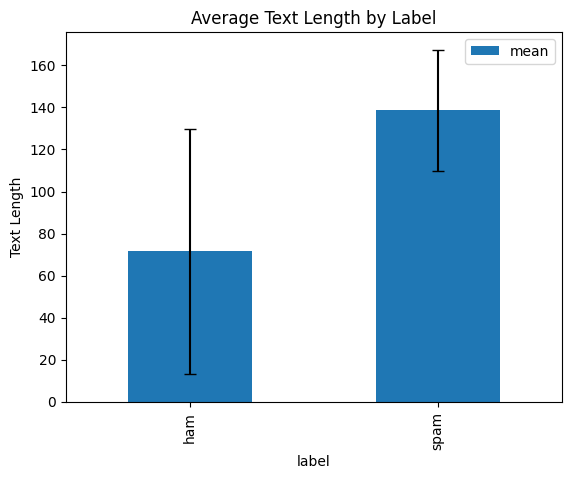

In [36]:
stats = df.groupby("label")["text_length"].agg(["mean", "std"])

stats.plot(
    kind = "bar",
    y = "mean",
    yerr = "std",    # error_bar는 표준편차
    capsize = 4
)

plt.ylabel("Text Length")
plt.title("Average Text Length by Label")
plt.show()

#■ Train/Test Split

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X = df["text"]
y = df["is_spam"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state=42, stratify=y
)

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

In [44]:
model_withstop = Pipeline([
    ("tfidf", TfidfVectorizer(
            max_features = 5000,
            ngram_range = (1, 2),
            stop_words = "english"
    )),
    ("clf", MultinomialNB())
])

In [45]:
model_withstop.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf', MultinomialNB())])

In [46]:
y_pred_withstop = model_withstop.predict(X_test)

In [47]:
from sklearn.metrics import classification_report, confusion_matrix

In [48]:
print(classification_report(y_test, y_pred_withstop))
# FP는 발생하지 않고, FN만 발생

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       1.00      0.81      0.89       149

    accuracy                           0.97      1115
   macro avg       0.99      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [49]:
cm1 = confusion_matrix(y_test, y_pred_withstop)

In [50]:
import seaborn as sns

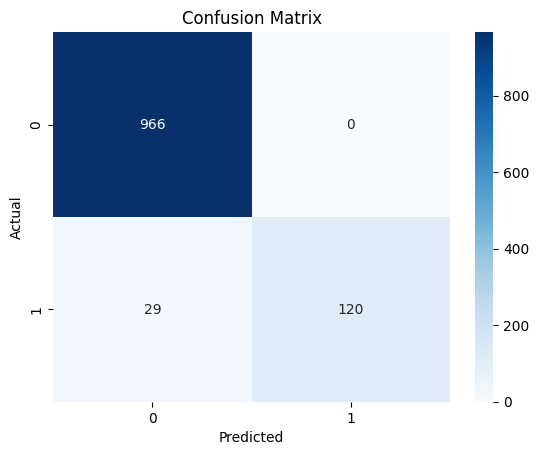

In [51]:
sns.heatmap(cm1, annot=True, fmt = "d", cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [59]:
results_withstop = pd.DataFrame({
    "text" : X_test,
    "actual" : y_test,
    "predicted" : y_pred_withstop,
    "text_length" : X_test.str.len()
})

results_withstop.head()

,text,actual,predicted,text_length
2825,No need to buy lunch for me.. I eat maggi mee..,0,0,47
3695,Ok im not sure what time i finish tomorrow but...,0,0,128
3904,Waiting in e car 4 my mum lor. U leh? Reach ho...,0,0,57
576,"You have won ?1,000 cash or a ?2,000 prize! To...",1,1,69
2899,If you r @ home then come down within 5 min,0,0,43


In [101]:
# FN 확인
results_FN1 = results_withstop[(results_withstop["actual"]==1)&(results_withstop["predicted"]==0)]

results_FN1.head()

,text,actual,predicted,text_length,spam_proba
5,FreeMsg Hey there darling it's been 3 week's n...,1,0,147,0.146873
3750,Dear Voucher Holder 2 claim your 1st class air...,1,0,147,0.471492
856,Talk sexy!! Make new friends or fall in love i...,1,0,144,0.301209
1663,Hi if ur lookin 4 saucy daytime fun wiv busty ...,1,0,159,0.194575
3981,ringtoneking 84484,1,0,18,0.299769


In [68]:
results_FN1["text_length"].describe()
# 길이가 길어서 놓친 것은 아닌 것 같음

,text_length
count,29.000000
mean,121.000000
std,44.940437
min,18.000000
25%,81.000000
50%,146.000000
75%,152.000000
max,181.000000


In [65]:
results_withstop.groupby("predicted")["text_length"].mean()

,text_length
predicted,
0,75.660302
1,141.450000


#■ Threshold별 FN, FP 비교

In [70]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [78]:
y_proba_withstop = model_withstop.predict_proba(X_test)[:, 1]

thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
threshold_results_withstop = []

for t in thresholds:
    y_pred_t = (y_proba_withstop >= t).astype(int)
    threshold_results_withstop.append({
        "threshold" : t,
        "precision" : precision_score(y_test, y_pred_t, zero_division=0),
        "recall" : recall_score(y_test, y_pred_t, zero_division=0),
        "f1" : f1_score(y_test, y_pred_t, zero_division=0)
    })

threshold_df_withstop = pd.DataFrame(threshold_results_withstop)
threshold_df_withstop

,threshold,precision,recall,f1
0,0.1,0.672897,0.966443,0.793388
1,0.3,0.984848,0.872483,0.925267
2,0.5,1.000000,0.805369,0.892193
3,0.7,1.000000,0.731544,0.844961
4,0.9,1.000000,0.590604,0.742616


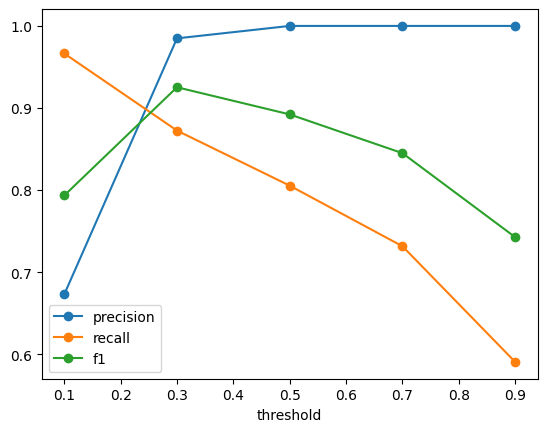

In [92]:
threshold_df_withstop.plot(
    x = "threshold",
    y = ["precision", "recall", "f1"],
    marker = "o")
plt.show()

In [102]:
results_withstop["spam_proba"] = y_proba_withstop
results_FN1.sort_values("spam_proba", ascending = False)
    # FN중 스팸 가능성이 높은것부터 보기

,text,actual,predicted,text_length,spam_proba
3856,Free msg: Single? Find a partner in your area!...,1,0,151,0.493945
3750,Dear Voucher Holder 2 claim your 1st class air...,1,0,147,0.471492
1460,Bought one ringtone and now getting texts cost...,1,0,81,0.469796
3272,You have 1 new voicemail. Please call 08719181...,1,0,50,0.426854
5110,You have 1 new message. Please call 08715205273,1,0,47,0.398660
1507,Thanks for the Vote. Now sing along with the s...,1,0,121,0.341517
5449,"Latest News! Police station toilet stolen, cop...",1,0,70,0.323220
4527,"I want some cock! My hubby's away, I need a re...",1,0,162,0.317993
4752,Your weekly Cool-Mob tones are ready to downlo...,1,0,160,0.317472
856,Talk sexy!! Make new friends or fall in love i...,1,0,144,0.301209


#■ stop이 없는 버전과 비교

In [93]:
model_withoutstop = Pipeline([
    ("tfidf", TfidfVectorizer(
            max_features = 5000,
            ngram_range = (1, 2)
    )),
    ("clf", MultinomialNB())
])

In [94]:
model_withoutstop.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
                ('clf', MultinomialNB())])

In [95]:
y_pred_withoutstop = model_withoutstop.predict(X_test)

In [96]:
print(classification_report(y_test, y_pred_withoutstop))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       1.00      0.81      0.89       149

    accuracy                           0.97      1115
   macro avg       0.99      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [97]:
cm2 = confusion_matrix(y_test, y_pred_withoutstop)

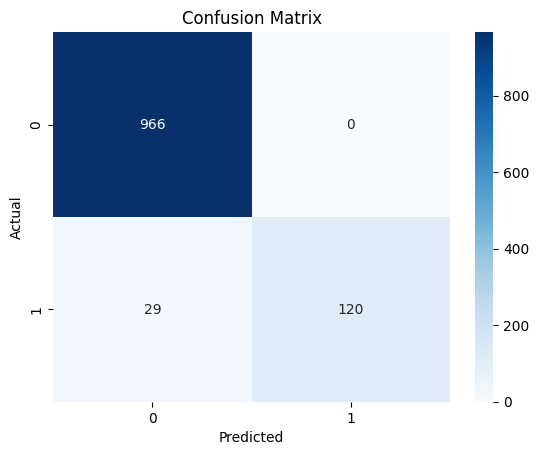

In [98]:
sns.heatmap(cm2, annot=True, fmt = "d", cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# stopword가 있는 버전 / 없는 버전의 차이가 없음